In [2]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.6/351.2 MB 11.9 MB/s eta 0:00:30
   ---------------------------------------- 4.2/351.2 MB 12.5 MB/s eta 0:00:28
    --------------------------------------- 5.5/351.2 MB 10.3 MB/s eta 0:00:34
    --------------------------------------- 5.8/351.2 MB 8.2 MB/s eta 0:00:43
    --------------------------------------- 7.1/351.2 MB 7.3 MB/s eta 0:00:47
    --------------------------------------- 7.9/351.2 MB 6.4 MB/s eta 0:00:54
    --------------------------------------- 8.4/351.2 MB 6.2 MB/s eta 0:00:56
   - -------------------------------------- 9.2/351.2 MB 5.7 MB/s eta 0:01:01
   - -------------------------------------- 9.7/351.2 MB 5.2 MB/s eta 0:01:06
   - -------------------------------------- 10.2/351.2 MB 5.0 MB/s eta 0:01:09
   - -------------------------------------- 10.7/351.2 MB 4.8 MB/s eta 0:01:12
   - -------------------------------------- 11.3/351.2 MB 4.6 MB/s

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [25]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [3]:
import numpy as np
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1]) 

weights = np.zeros(2)
bias = 0

learning_rate = 0.1
epochs = 10

for epoch in range(epochs):
    for i in range(len(X)):
        net = np.dot(X[i], weights) + bias
        output = 1 if net >= 0 else 0
        error = y[i] - output
        weights += learning_rate * error * X[i]
        bias += learning_rate * error
print("Final Weights:", weights)
print("Final Bias:", bias)

print("\nPredictions:")
for x in X:
    net = np.dot(x, weights) + bias
    prediction = 1 if net >= 0 else 0
    print(x, "->", prediction)

Final Weights: [0.1 0.1]
Final Bias: -0.1

Predictions:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

model = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X, y, epochs=200, verbose=0)

loss, acc = model.evaluate(X, y, verbose=0)
print("Accuracy:", acc)

Accuracy: 0.5


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

configs = [
    (0.01,4,0.0),
    (0.01,8,0.2),
    (0.001,4,0.2),
    (0.001,8,0.3),
    (0.005,16,0.2)
]

for lr, neurons, drop in configs:

    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(2,)),
        Dropout(drop),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(X, y, epochs=100, verbose=0)

    loss, acc = model.evaluate(X, y, verbose=0)

    print("Learning Rate:", lr)
    print("Hidden Units:", neurons)
    print("Dropout:", drop)
    print("Loss:", loss)
    print("Accuracy:", acc)

Learning Rate: 0.01
Hidden Units: 4
Dropout: 0.0
Loss: 0.43780651688575745
Accuracy: 0.75
Learning Rate: 0.01
Hidden Units: 8
Dropout: 0.2
Loss: 0.4680180251598358
Accuracy: 1.0
Learning Rate: 0.001
Hidden Units: 4
Dropout: 0.2
Loss: 0.8896662592887878
Accuracy: 0.75
Learning Rate: 0.001
Hidden Units: 8
Dropout: 0.3
Loss: 0.6745900511741638
Accuracy: 0.5
Learning Rate: 0.005
Hidden Units: 16
Dropout: 0.2
Loss: 0.4836449921131134
Accuracy: 1.0


In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = Sequential([
    Flatten(input_shape=(28, 28)),  

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(10, activation='softmax') 
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

loss, accuracy = model.evaluate(x_test, y_test)

print(f"\nTest Accuracy: {accuracy:.4f}")
prediction = model.predict(x_test[:1])

print("Predicted Digit:", prediction.argmax())
print("Actual Digit:", y_test[0])

C:\Users\Shanjana\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9271 - loss: 0.2490 - val_accuracy: 0.9652 - val_loss: 0.1151
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9684 - loss: 0.1041 - val_accuracy: 0.9750 - val_loss: 0.0840
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9769 - loss: 0.0743 - val_accuracy: 0.9730 - val_loss: 0.0958
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9819 - loss: 0.0561 - val_accuracy: 0.9777 - val_loss: 0.0830
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9864 - loss: 0.0441 - val_accuracy: 0.9722 - val_loss: 0.0989
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9882 - loss: 0.0363 - val_accuracy: 0.9770 - val_loss: 0.0974
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9902 - loss: 0.0299 - val_accuracy: 0.9772 - val_loss: 0.0890
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9916 - loss: 0

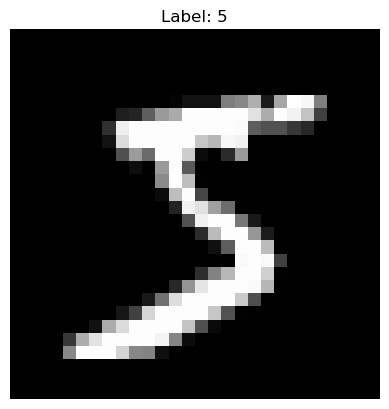

In [30]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

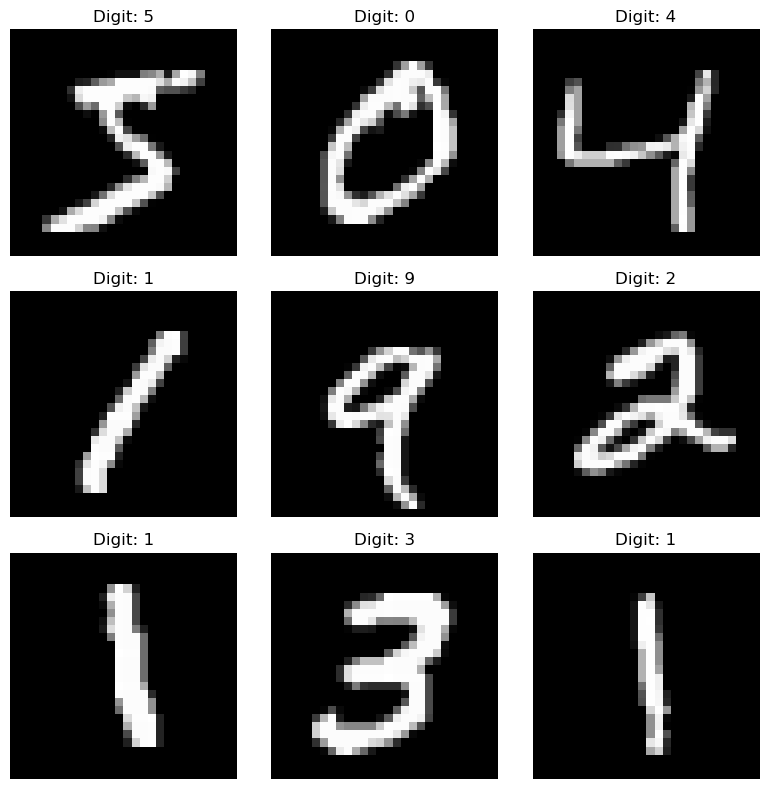

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Digit: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


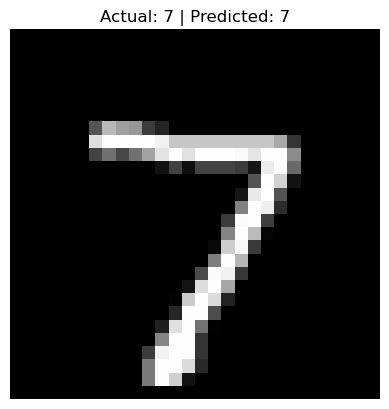

In [32]:
prediction = model.predict(x_test[:1])

plt.imshow(x_test[0], cmap='gray')
plt.title(
    f"Actual: {y_test[0]} | Predicted: {prediction.argmax()}"
)
plt.axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


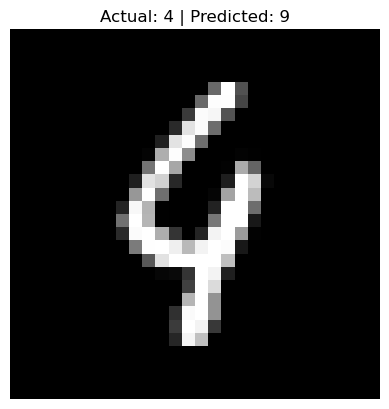

In [33]:
predictions = model.predict(x_test)
predicted_labels = predictions.argmax(axis=1)

for i in range(len(x_test)):
    if predicted_labels[i] != y_test[i]:
        plt.imshow(x_test[i], cmap='gray')
        plt.title(
            f"Actual: {y_test[i]} | Predicted: {predicted_labels[i]}"
        )
        plt.axis('off')
        plt.show()
        break